In [ ]:
#create a separate script for bar plots for factor scores (worry, moodiness, and social disinterest) that are colored by domain and subdomain for plotting (keeping separate from other scripts so as to not clutter)
#load necessary packages
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

#load data - mat file and csv file
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')
data = loadmat('Clinical_Outcomes_Workspace.mat')
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")

/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [7]:
#load vars
depind = data['depind']   #dep indices                 # 2743 x 68
a = data['a'] #loadings variable with full list
hcind = data['hcind'] #hc indices
age = data['age'].ravel()
Location_ID = data['Location_ID'].ravel()
sex_coded = data['sex_coded'].ravel()
worry_rumination = data['Worry_Rumination'].ravel()
moodiness = data['Moodiness'].ravel()
social_disinterest = data['Social_Disinterest'].ravel()
all_matrices_dep = data['all_matrices_dep']

# --- FIX: Load Labels correctly ---
# MATLAB often stores strings as nested arrays of dtype=object
if 'Labels' in data:
    Labels = data['Labels']
    clean_labels = [str(lbl[0]) for lbl in Labels.squeeze()]
else:
    clean_labels = None
    print("⚠️ WARNING: 'Labels' not found in .mat file")


In [12]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection

# ---------------------------------------------------------
# Inputs
# ---------------------------------------------------------

# a = your ICA loading matrix (subjects × components)
# clean_labels = list of component labels (length = number of components)

hcind  = np.arange(0, 76)          # Python is 0‑indexed
depind = np.arange(76, 2819)

# ---------------------------------------------------------
# Two-sample t-test
# ---------------------------------------------------------

tvals, pvals = ttest_ind(a[hcind, :], a[depind, :], axis=0, equal_var=False)

# ---------------------------------------------------------
# FDR correction
# ---------------------------------------------------------

reject, qvals = fdrcorrection(pvals)

# ---------------------------------------------------------
# Build dataframe with all results
# ---------------------------------------------------------

df = pd.DataFrame({
    "Component": np.arange(1, a.shape[1] + 1),
    "Label": clean_labels,
    "p_value": pvals,
    "q_value": qvals,
    "t_stat": tvals
})

# ---------------------------------------------------------
# Significant sets
# ---------------------------------------------------------

# p < 0.05
pos_p05 = df[(df.p_value < 0.05) & (df.t_stat > 0)]
neg_p05 = df[(df.p_value < 0.05) & (df.t_stat < 0)]

# q < 0.05
all_q05 = df[df.q_value < 0.05]
pos_q05 = all_q05[all_q05.t_stat > 0]
neg_q05 = all_q05[all_q05.t_stat < 0]

# q < 0.01  (NEW: full list + pos/neg splits)
all_q01 = df[df.q_value < 0.01]
pos_q01 = all_q01[all_q01.t_stat > 0]
neg_q01 = all_q01[all_q01.t_stat < 0]

# ---------------------------------------------------------
# Display results with counts
# ---------------------------------------------------------


print("\n=== Positive components (p < 0.05) ===")
display(pos_p05)
print(f"Count: {len(pos_p05)}")

print("\n=== Negative components (p < 0.05) ===")
display(neg_p05)
print(f"Count: {len(neg_p05)}")

print("\n=== ALL components (q < 0.05) ===")
display(all_q05)
print(f"Count: {len(all_q05)}")

print("\n=== Positive components (q < 0.05) ===")
display(pos_q05)
print(f"Count: {len(pos_q05)}")

print("\n=== Negative components (q < 0.05) ===")
display(neg_q05)
print(f"Count: {len(neg_q05)}")

print("\n=== ALL components (q < 0.01) ===")
display(all_q01)
print(f"Count: {len(all_q01)}")

print("\n=== Positive components (q < 0.01) ===")
display(pos_q01)
print(f"Count: {len(pos_q01)}")

print("\n=== Negative components (q < 0.01) ===")
display(neg_q01)
print(f"Count: {len(neg_q01)}")



=== Positive components (p < 0.05) ===


,Component,Label,p_value,q_value,t_stat
8,9,cerebellum,1.295820e-04,3.831121e-04,4.025914
9,10,HC-FR,4.372881e-02,7.079903e-02,2.049811
13,14,HC-FR,3.396392e-03,7.698489e-03,3.018925
15,16,HC-FR,4.913990e-05,1.591197e-04,4.295193
16,17,HC-FR,3.078319e-04,8.373028e-04,3.774597
17,18,HC-FR,1.077160e-02,2.186663e-02,2.612137
18,19,HC-TP,1.885872e-05,6.749435e-05,4.552024
20,21,HC-TP,3.660314e-09,2.262739e-08,6.627571
21,22,HC-TP,7.657145e-04,1.859592e-03,3.499622
24,25,HC-TP,2.316809e-04,6.564292e-04,3.855062


Count: 24

=== Negative components (p < 0.05) ===


,Component,Label,p_value,q_value,t_stat
1,2,cerebellum,7.632508e-04,1.859592e-03,-3.503822
5,6,cerebellum,1.143101e-11,8.636761e-11,-7.955848
14,15,HC-FR,2.631756e-03,6.171015e-03,-3.106553
22,23,HC-TP,3.378709e-02,5.743805e-02,-2.160269
28,29,HC-IT,2.288120e-02,4.445490e-02,-2.320132
31,32,SC-BG,6.979108e-19,1.186448e-17,-11.583339
32,33,SC-BG,1.093332e-02,2.186663e-02,-2.604610
35,36,SC-EH,4.245875e-15,4.124564e-14,-9.661998
37,38,SC-ET,2.493838e-20,5.652698e-19,-12.322667
40,41,sensorimotor,1.988045e-05,6.759352e-05,-4.539288


Count: 18

=== ALL components (q < 0.05) ===


...

Count: 31

=== Positive components (q < 0.01) ===


,Component,Label,p_value,q_value,t_stat
8,9,cerebellum,1.295820e-04,3.831121e-04,4.025914
13,14,HC-FR,3.396392e-03,7.698489e-03,3.018925
15,16,HC-FR,4.913990e-05,1.591197e-04,4.295193
16,17,HC-FR,3.078319e-04,8.373028e-04,3.774597
18,19,HC-TP,1.885872e-05,6.749435e-05,4.552024
20,21,HC-TP,3.660314e-09,2.262739e-08,6.627571
21,22,HC-TP,7.657145e-04,1.859592e-03,3.499622
24,25,HC-TP,2.316809e-04,6.564292e-04,3.855062
25,26,HC-TP,3.314674e-17,4.507956e-16,10.783469
26,27,HC-TP,7.111895e-04,1.859592e-03,3.521691


Count: 18

=== Negative components (q < 0.01) ===


,Component,Label,p_value,q_value,t_stat
1,2,cerebellum,7.632508e-04,1.859592e-03,-3.503822
5,6,cerebellum,1.143101e-11,8.636761e-11,-7.955848
14,15,HC-FR,2.631756e-03,6.171015e-03,-3.106553
31,32,SC-BG,6.979108e-19,1.186448e-17,-11.583339
35,36,SC-EH,4.245875e-15,4.124564e-14,-9.661998
37,38,SC-ET,2.493838e-20,5.652698e-19,-12.322667
40,41,sensorimotor,1.988045e-05,6.759352e-05,-4.539288
49,50,TN-DM,1.475229e-07,7.165400e-07,-5.768298
53,54,TN-DM,6.289547e-07,2.673058e-06,-5.421053
55,56,TN-DM,4.084728e-07,1.851743e-06,-5.523450


Count: 13


/var/folders/2r/lcd0_jwn383gpby4x6q6v5100000gn/T/ipykernel_5445/3319763053.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_cats))


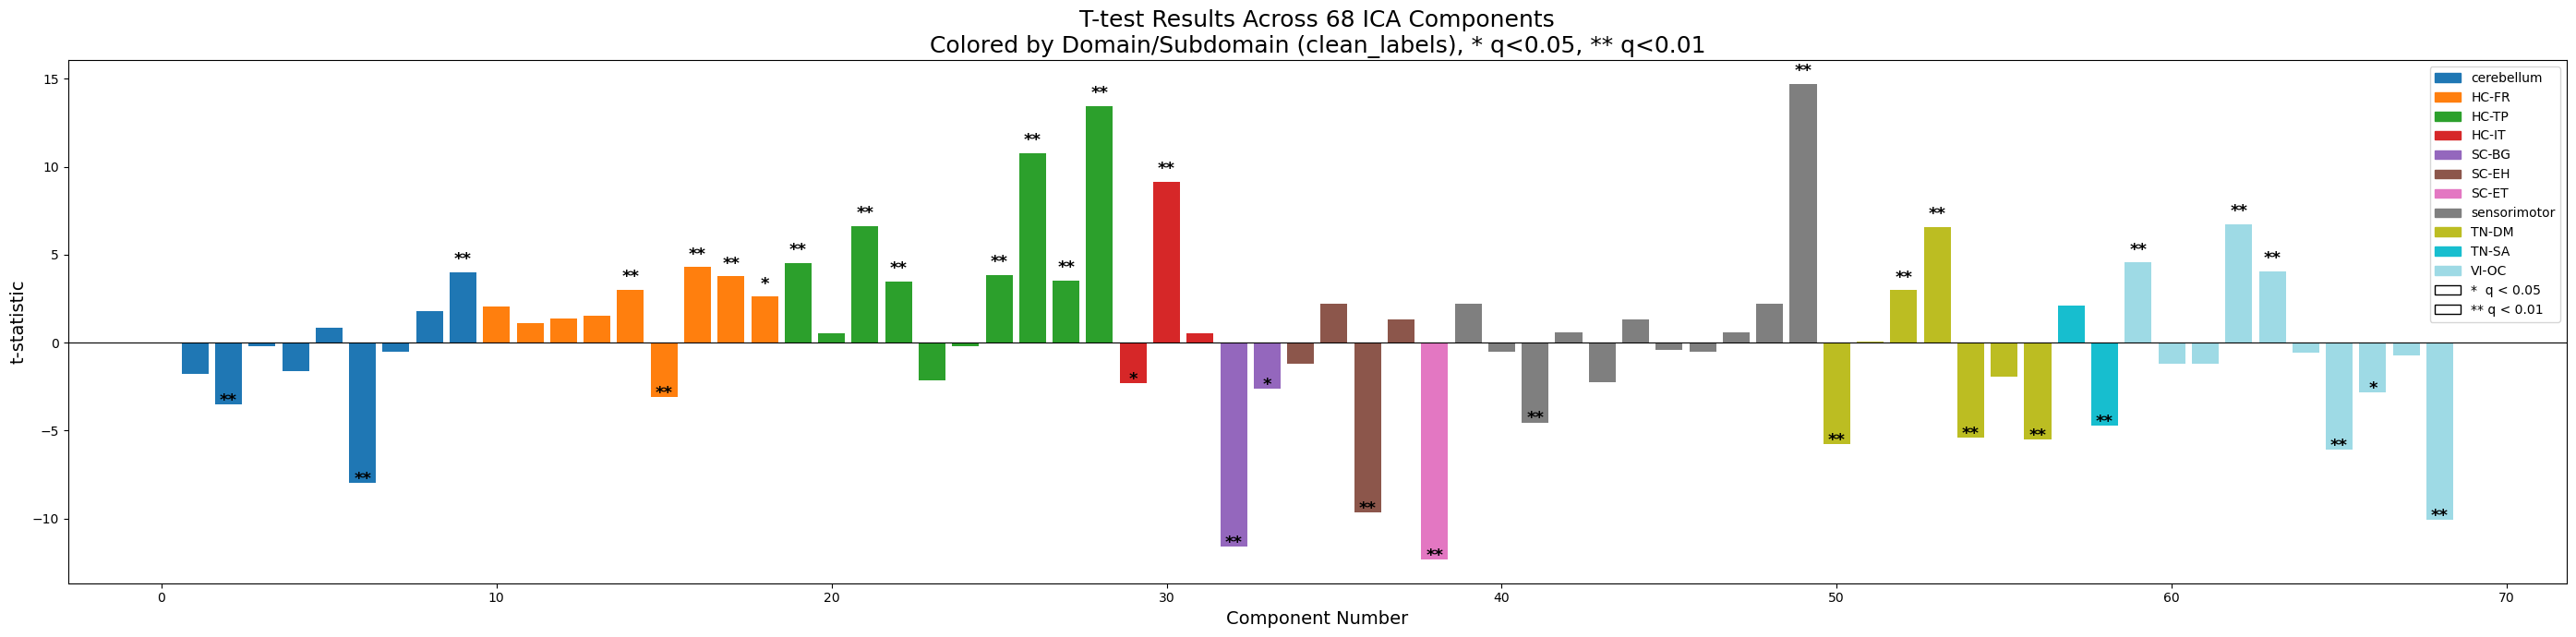

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Use clean_labels directly as categories
# ---------------------------------------------------------

# Unique categories in order of appearance
unique_cats = list(dict.fromkeys(clean_labels))

# Assign each category a color
cmap = cm.get_cmap("tab20", len(unique_cats))
category_to_color = {cat: cmap(i) for i, cat in enumerate(unique_cats)}

# Map each component to its category color
df["Color"] = df["Label"].map(category_to_color)

# ---------------------------------------------------------
# Significance markers
# ---------------------------------------------------------

sig_markers = []
for q in df["q_value"]:
    if q < 0.01:
        sig_markers.append("**")
    elif q < 0.05:
        sig_markers.append("*")
    else:
        sig_markers.append("")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(28, 7))

bars = plt.bar(df["Component"], df["t_stat"], color=df["Color"])

# Add significance stars
for comp, t, mark in zip(df["Component"], df["t_stat"], sig_markers):
    if mark:
        plt.text(
            comp,
            t + np.sign(t) * 0.25,
            mark,
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )

# ---------------------------------------------------------
# Labels and formatting
# ---------------------------------------------------------

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Component Number", fontsize=14)
plt.ylabel("t-statistic", fontsize=14)
plt.title(
    "T-test Results Across 68 ICA Components\n"
    "Colored by Domain/Subdomain (clean_labels), * q<0.05, ** q<0.01",
    fontsize=18
)

# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

import matplotlib.patches as mpatches

label_patches = [
    mpatches.Patch(color=category_to_color[cat], label=cat)
    for cat in unique_cats
]

star1 = mpatches.Patch(facecolor="white", edgecolor="black", label="*  q < 0.05")
star2 = mpatches.Patch(facecolor="white", edgecolor="black", label="** q < 0.01")

plt.legend(
    handles=label_patches + [star1, star2],
    fontsize=10,
    loc="upper right",
    ncol=1
)

plt.tight_layout()
plt.show()
